# EDA Dataset Chatbot

In [42]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('diabetes_merged_dataset.csv')
df.head()



,question,answer
0,"What are some examples of calorie-free, caffei...","Examples of calorie-free, caffeine-free liquid..."
1,Why is it important for individuals with diabe...,Staying hydrated is crucial for regulating blo...
2,What type of gelatin is recommended for indivi...,Individuals with diabetes should choose gelati...
3,In what situations should an individual with d...,Individuals with diabetes should contact their...
4,Why is it important for individuals with diabe...,Wearing medical identification alerts others t...


In [43]:

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nUnique Questions:", df['question'].nunique())
print("Unique Answers:", df['answer'].nunique())


Shape: (32323, 2)

Columns:
['question', 'answer']

Missing Values:
question    0
answer      0
dtype: int64

Duplicate Rows: 219

Unique Questions: 32087
Unique Answers: 26109


In [ ]:

df['question_length_words'] = df['question'].astype(str).apply(lambda x: len(x.split()))
df['answer_length_words'] = df['answer'].astype(str).apply(lambda x: len(x.split()))

df[['question_length_words','answer_length_words']].describe()


,question_length_words,answer_length_words
count,32323.000000,32323.000000
mean,14.328837,58.231383
std,3.292243,23.636838
min,1.000000,9.000000
25%,12.000000,47.000000
50%,14.000000,49.000000
75%,17.000000,51.000000
max,32.000000,114.000000


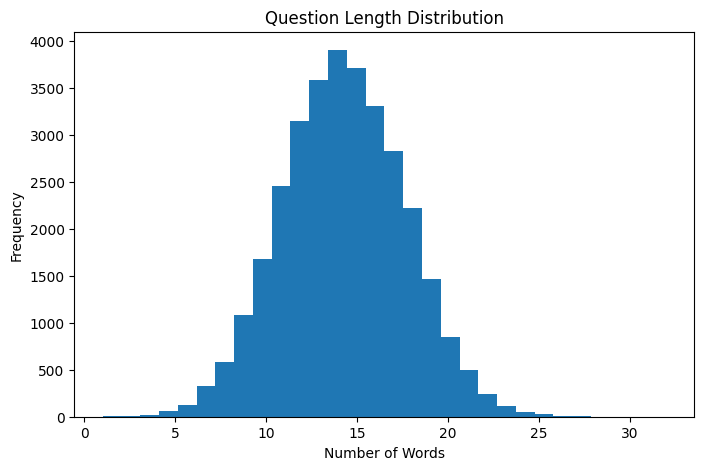

In [35]:

plt.figure(figsize=(8,5))
plt.hist(df['question_length_words'], bins=30)
plt.title('Question Length Distribution')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()


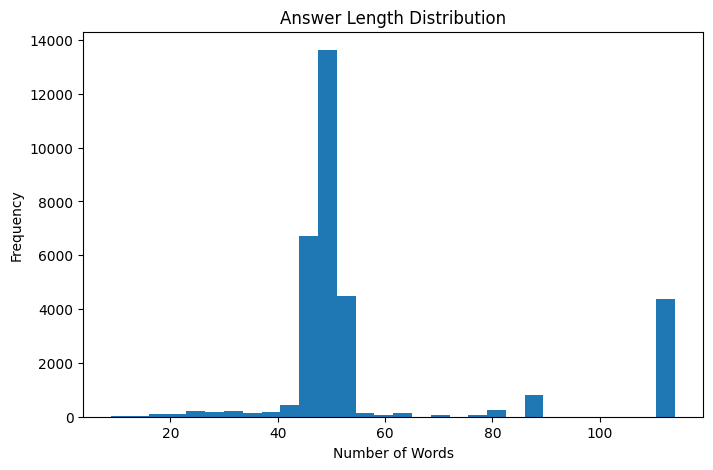

In [36]:

plt.figure(figsize=(8,5))
plt.hist(df['answer_length_words'], bins=30)
plt.title('Answer Length Distribution')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()


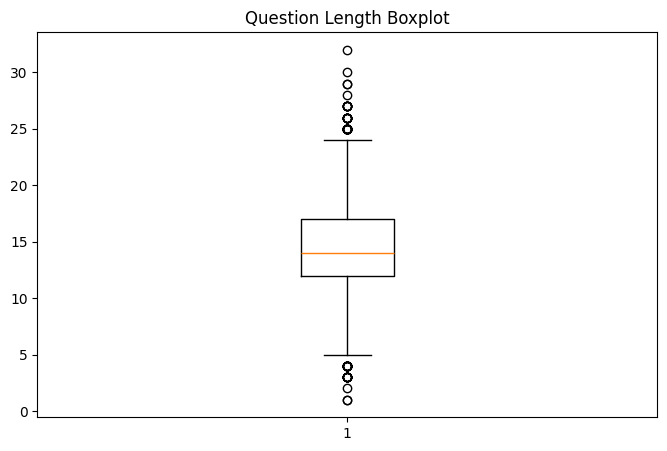

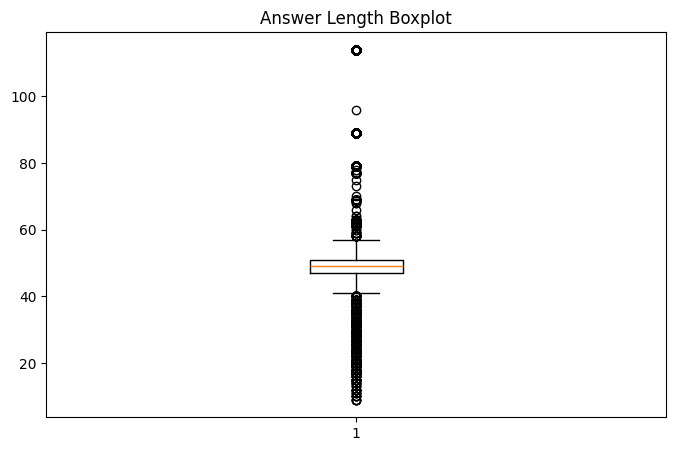

In [37]:

plt.figure(figsize=(8,5))
plt.boxplot(df['question_length_words'])
plt.title('Question Length Boxplot')
plt.show()

plt.figure(figsize=(8,5))
plt.boxplot(df['answer_length_words'])
plt.title('Answer Length Boxplot')
plt.show()


In [ ]:

from collections import Counter
from nltk.corpus import stopwords
import re

text = ' '.join(df['question'].astype(str))

words = re.findall(r'[a-zA-Z]+', text.lower())

# stopwords = {
# 'the','a','an','is','are','am','was','were','be','been',
# 'what','why','how','when','where','who','which',
# 'to','of','in','on','for','with','and','or','my','i','me','it'
# }

stop_words = stopwords.words('english')
words = [w for w in words if w not in stop_words]
top_words = Counter(words).most_common(20)
top_df = pd.DataFrame(top_words, columns=['Word','Frequency'])
top_df


,Word,Frequency
0,diabetes,13116
1,compare,4389
2,vs,4389
3,type,3461
4,blood,3429
5,feel,3281
6,sugar,3236
7,insulin,3218
8,really,2894
9,get,2298


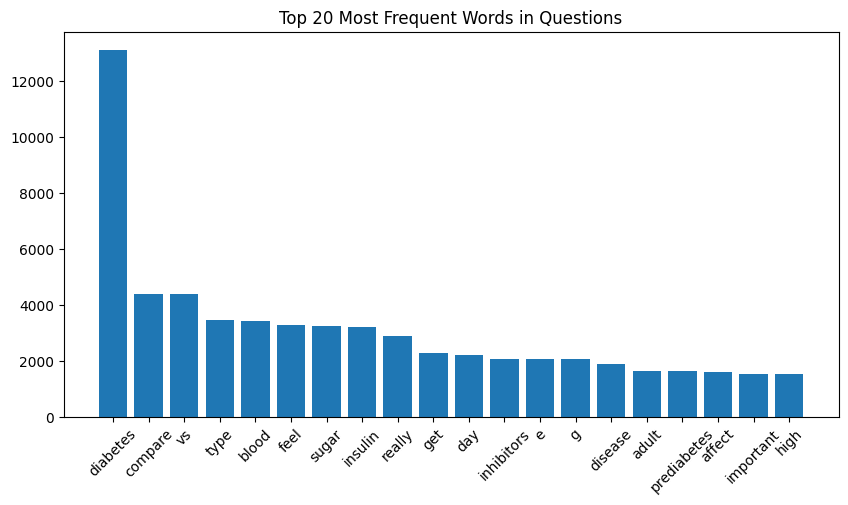

In [39]:

plt.figure(figsize=(10,5))
plt.bar(top_df['Word'], top_df['Frequency'])
plt.xticks(rotation=45)
plt.title('Top 20 Most Frequent Words in Questions')
plt.show()
